# CH'27 — Hub-Level Demand Forecasting
### Celebal Technologies × VIT Vellore — Data Science Hiring Challenge

**Goal:** Predict daily `OrderVolume` for each micro-fulfillment hub over a future 6-week window.

**Metric:** Root Mean Squared Logarithmic Error (RMSLE)

**Files:**
- `orders_train.csv` — historical daily orders + operating context (2013-01-01 → 2015-06-19)
- `orders_test.csv` — future dates to predict (2015-06-20 → 2015-07-31)
- `hub_metadata.csv` — static hub attributes (1,115 hubs)

**Pipeline overview:**
1. Setup & configuration
2. Load data
3. Exploratory data analysis (EDA)
4. Data cleaning
5. Merge hub metadata
6. Feature engineering (calendar, hub, lag/rolling)
7. Target transformation
8. Time-based validation split
9. Encoding
10. Model training (LightGBM + CatBoost)
11. Validation & feature importance
12. Ensembling
13. Final training on full data + test prediction
14. Submission file


## 1. Setup & Configuration

In [1]:
# Core libraries
import os
import gc
import json
import warnings
from datetime import datetime

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ---- Model libraries (guarded imports so the notebook still runs
#      even on a machine where lightgbm / catboost aren't installed —
#      falls back to sklearn's HistGradientBoostingRegressor) ----
try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False
    print("lightgbm not available — install with `pip install lightgbm` for the full pipeline")

try:
    from catboost import CatBoostRegressor, Pool
    HAS_CATBOOST = True
except ImportError:
    HAS_CATBOOST = False
    print("catboost not available — install with `pip install catboost` for the full pipeline")

from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_squared_error

print("HAS_LGB:", HAS_LGB, "| HAS_CATBOOST:", HAS_CATBOOST)


HAS_LGB: True | HAS_CATBOOST: True


In [2]:
# ---- File paths ----
DATA_DIR = "."  # change to the folder containing the competition CSVs

PATH_TRAIN = os.path.join(DATA_DIR, "orders_train.csv")
PATH_TEST = os.path.join(DATA_DIR, "orders_test.csv")
PATH_HUB_META = os.path.join(DATA_DIR, "hub_metadata.csv")
PATH_SAMPLE_SUB = os.path.join(DATA_DIR, "sample_submission.csv")

# How many days of test horizon to hold out from the *end* of train
# for local validation (mirrors the actual test window length so the
# local CV score is a fair proxy for the private leaderboard).
VALIDATION_HORIZON_DAYS = 42  # ~6 weeks, matches orders_test.csv span


## 2. Load Data

Load the three competition files and the sample submission (to confirm the expected output format).

In [3]:
train = pd.read_csv(PATH_TRAIN, parse_dates=["Date"])
test = pd.read_csv(PATH_TEST, parse_dates=["Date"])
hub_meta = pd.read_csv(PATH_HUB_META)
sample_sub = pd.read_csv(PATH_SAMPLE_SUB)

print("train :", train.shape)
print("test  :", test.shape)
print("hub   :", hub_meta.shape)
print("sample:", sample_sub.shape)

train.head()


train : (970379, 9)
test  : (46830, 8)
hub   : (1115, 10)
sample: (46830, 2)


,HubID,Weekday,Date,OrderVolume,AppSessions,IsOpen,PromoActive,RegionalHoliday,SchoolClosureFlag
0,1,2,2013-01-01,0,0,0,0,1,1
1,2,2,2013-01-01,0,0,0,0,1,1
2,3,2,2013-01-01,0,0,0,0,1,1
3,4,2,2013-01-01,0,0,0,0,1,1
4,5,2,2013-01-01,0,0,0,0,1,1


In [4]:
test.head()


,Id,HubID,Weekday,Date,IsOpen,PromoActive,RegionalHoliday,SchoolClosureFlag
0,1,1,6,2015-06-20,1,0,0,0
1,2,2,6,2015-06-20,1,0,0,0
2,3,3,6,2015-06-20,1,0,0,0
3,4,4,6,2015-06-20,1,0,0,0
4,5,5,6,2015-06-20,1,0,0,0


In [5]:
hub_meta.head()


,HubID,HubFormat,AssortmentTier,CompetitorDistance,CompetitorOpenSinceMonth,CompetitorOpenSinceYear,LoyaltyProgram,LoyaltyProgramSinceWeek,LoyaltyProgramSinceYear,LoyaltyProgramInterval
0,1,3,1,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,1,1,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,1,1,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,3,3,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,1,1,29910.0,4.0,2015.0,0,NaN,NaN,NaN


## 3. Exploratory Data Analysis (EDA)

Quick checks: dtypes, missing values, date coverage, target distribution, and how the operational
flags relate to `OrderVolume`. This drives the feature-engineering and cleaning decisions below.

In [6]:
print("---- dtypes (train) ----")
print(train.dtypes)
print()
print("---- missing values ----")
print("train:\n", train.isna().sum())
print("\ntest:\n", test.isna().sum())
print("\nhub_meta:\n", hub_meta.isna().sum())


---- dtypes (train) ----
HubID                         int64
Weekday                       int64
Date                 datetime64[us]
OrderVolume                   int64
AppSessions                   int64
IsOpen                        int64
PromoActive                   int64
RegionalHoliday               int64
SchoolClosureFlag             int64
dtype: object

---- missing values ----
train:
 HubID                0
Weekday              0
Date                 0
OrderVolume          0
AppSessions          0
IsOpen               0
PromoActive          0
RegionalHoliday      0
SchoolClosureFlag    0
dtype: int64

test:
 Id                   0
HubID                0
Weekday              0
Date                 0
IsOpen               0
PromoActive          0
RegionalHoliday      0
SchoolClosureFlag    0
dtype: int64

hub_meta:
 HubID                         0
HubFormat                     0
AssortmentTier                0
CompetitorDistance            3
CompetitorOpenSinceMonth    354
Compet

In [7]:
print("Train date range:", train.Date.min().date(), "->", train.Date.max().date())
print("Test  date range:", test.Date.min().date(), "->", test.Date.max().date())
print("Gap between train end and test start:",
      (test.Date.min() - train.Date.max()).days, "day(s)  (should be 1 -> no leakage window)")
print()
print("Unique hubs — train:", train.HubID.nunique(),
      "| test:", test.HubID.nunique(),
      "| metadata:", hub_meta.HubID.nunique())


Train date range: 2013-01-01 -> 2015-06-19
Test  date range: 2015-06-20 -> 2015-07-31
Gap between train end and test start: 1 day(s)  (should be 1 -> no leakage window)

Unique hubs — train: 1115 | test: 1115 | metadata: 1115


In [8]:
print("OrderVolume summary:")
print(train.OrderVolume.describe())
print()
print("Fraction of zero-volume rows:", round((train.OrderVolume == 0).mean(), 4))
print("Fraction of IsOpen == 0 rows:", round((train.IsOpen == 0).mean(), 4))
print()
# Almost all zero-volume rows should coincide with closed hubs (renovation/holiday closures)
zero_vol = train.OrderVolume == 0
print("Zero volume while IsOpen==1 (data-quality check):",
      (zero_vol & (train.IsOpen == 1)).sum(), "rows")


OrderVolume summary:
count    970379.000000
mean       5762.766017
std        3855.457183
min           0.000000
25%        3708.000000
50%        5736.000000
75%        7850.000000
max       38722.000000
Name: OrderVolume, dtype: float64

Fraction of zero-volume rows: 0.1714
Fraction of IsOpen == 0 rows: 0.1713

Zero volume while IsOpen==1 (data-quality check): 54 rows


In [9]:
# Sanity check on test set's IsOpen — the task states operational status is *planned*,
# so a hub marked IsOpen==0 in test should get a forced prediction of 0.
print(test.IsOpen.value_counts())
print("\nAny NaNs in test.IsOpen?", test.IsOpen.isna().any())


IsOpen
1    40282
0     6548
Name: count, dtype: int64

Any NaNs in test.IsOpen? False


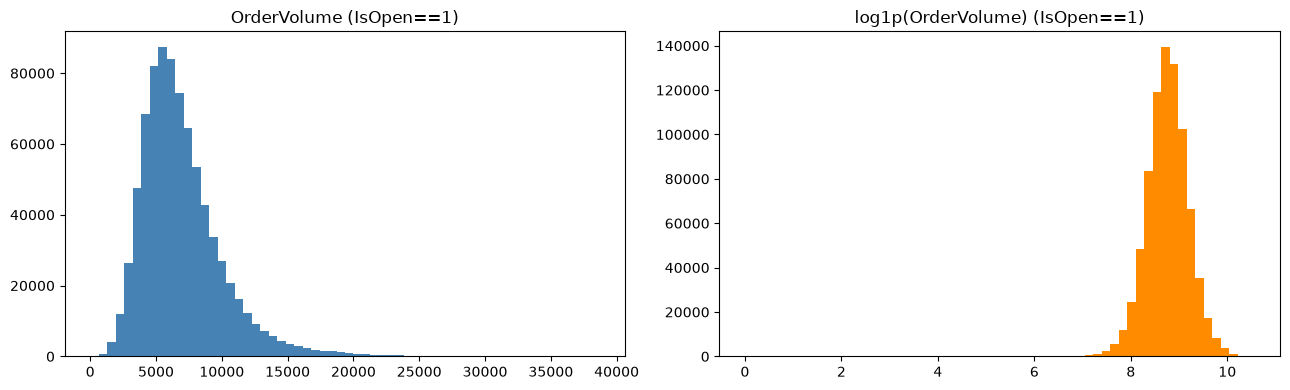

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution of raw OrderVolume vs log1p(OrderVolume) for open hubs only
open_train = train[train.IsOpen == 1]
axes[0].hist(open_train.OrderVolume, bins=60, color="steelblue")
axes[0].set_title("OrderVolume (IsOpen==1)")

axes[1].hist(np.log1p(open_train.OrderVolume), bins=60, color="darkorange")
axes[1].set_title("log1p(OrderVolume) (IsOpen==1)")
plt.tight_layout()
plt.show()


In [11]:
# Average order volume by weekday and by promo flag — sanity-check the signal strength
# of the operational features before engineering on top of them.
display(train.groupby("Weekday").OrderVolume.mean().rename("avg_order_volume"))
display(train.groupby("PromoActive").OrderVolume.mean().rename("avg_order_volume"))
display(train.groupby("RegionalHoliday").OrderVolume.mean().rename("avg_order_volume"))


Weekday
1    7789.810555
2    6990.017140
3    6543.865120
4    6221.276095
5    6709.536510
6    5857.735540
7     202.175724
Name: avg_order_volume, dtype: float64

PromoActive
0    4395.015455
1    7969.052220
Name: avg_order_volume, dtype: float64

RegionalHoliday
0    5944.723595
1     290.735686
2     214.311510
3     168.733171
Name: avg_order_volume, dtype: float64

## 4. Data Cleaning

Key decisions:
- **Closed hubs (`IsOpen == 0`) always have `OrderVolume == 0`.** These rows add noise if used for
  training a *demand* model, so we drop them from the training set and instead hard-code
  `prediction = 0` for any closed hub in the test set at the very end.
- **Missing hub metadata** (`CompetitorDistance`, `CompetitorOpenSince*`, `LoyaltyProgramSince*`)
  is structurally missing (e.g. no competitor / no loyalty program yet), so we impute with
  sentinel values and add "has/hasn't" indicator flags rather than imputing a misleading mean.

In [12]:
# Drop closed-hub rows from the training target (won't help predict demand on open days)
n_before = len(train)
train_open = train[train.IsOpen == 1].copy()
print(f"Dropped {n_before - len(train_open):,} closed-hub rows "
      f"({(n_before - len(train_open)) / n_before:.1%} of train)")

# Keep track of which test rows are closed -> force these to 0 later, no modelling needed
test_closed_mask = (test.IsOpen == 0)
print(f"Closed-hub rows in test: {test_closed_mask.sum():,} / {len(test):,}")


Dropped 166,269 closed-hub rows (17.1% of train)
Closed-hub rows in test: 6,548 / 46,830


In [13]:
hub_meta_clean = hub_meta.copy()

# --- Competitor info: missing = no known nearby competitor ---
hub_meta_clean["HasCompetitor"] = hub_meta_clean["CompetitorDistance"].notna().astype(int)
hub_meta_clean["CompetitorDistance"] = hub_meta_clean["CompetitorDistance"].fillna(
    hub_meta_clean["CompetitorDistance"].max() * 2  # "far away" sentinel
)
hub_meta_clean["CompetitorOpenSinceMonth"] = hub_meta_clean["CompetitorOpenSinceMonth"].fillna(0)
hub_meta_clean["CompetitorOpenSinceYear"] = hub_meta_clean["CompetitorOpenSinceYear"].fillna(0)

# --- Loyalty programme info: missing = hub never enrolled ---
hub_meta_clean["LoyaltyProgramSinceWeek"] = hub_meta_clean["LoyaltyProgramSinceWeek"].fillna(0)
hub_meta_clean["LoyaltyProgramSinceYear"] = hub_meta_clean["LoyaltyProgramSinceYear"].fillna(0)
hub_meta_clean["LoyaltyProgramInterval"] = hub_meta_clean["LoyaltyProgramInterval"].fillna("None")

hub_meta_clean.isna().sum()


HubID                       0
HubFormat                   0
AssortmentTier              0
CompetitorDistance          0
CompetitorOpenSinceMonth    0
CompetitorOpenSinceYear     0
LoyaltyProgram              0
LoyaltyProgramSinceWeek     0
LoyaltyProgramSinceYear     0
LoyaltyProgramInterval      0
HasCompetitor               0
dtype: int64

## 5. Merge Hub Metadata

Join the static hub attributes onto every train/test row via `HubID`.

In [14]:
def merge_hub_metadata(df, hub_df):
    return df.merge(hub_df, on="HubID", how="left")

train_full = merge_hub_metadata(train_open, hub_meta_clean)
test_full = merge_hub_metadata(test, hub_meta_clean)

print(train_full.shape, test_full.shape)
train_full.head()


(804110, 19) (46830, 18)


,HubID,Weekday,Date,OrderVolume,AppSessions,IsOpen,PromoActive,RegionalHoliday,SchoolClosureFlag,HubFormat,AssortmentTier,CompetitorDistance,CompetitorOpenSinceMonth,CompetitorOpenSinceYear,LoyaltyProgram,LoyaltyProgramSinceWeek,LoyaltyProgramSinceYear,LoyaltyProgramInterval,HasCompetitor
0,85,2,2013-01-01,4220,619,1,0,1,1,2,1,1870.0,10.0,2011.0,0,0.0,0.0,None,1
1,259,2,2013-01-01,6851,1444,1,0,1,1,2,2,210.0,0.0,0.0,0,0.0,0.0,None,1
2,262,2,2013-01-01,17267,2875,1,0,1,1,2,1,1180.0,5.0,2013.0,0,0.0,0.0,None,1
3,274,2,2013-01-01,3102,729,1,0,1,1,2,2,3640.0,0.0,0.0,1,10.0,2013.0,"Jan,Apr,Jul,Oct",1
4,335,2,2013-01-01,2401,482,1,0,1,1,2,1,90.0,0.0,0.0,1,31.0,2013.0,"Jan,Apr,Jul,Oct",1


## 6. Feature Engineering

Three families of features:

1. **Calendar features** — derived purely from `Date`, safe to compute identically on
   train and test (no leakage).
2. **Hub lifecycle features** — how long a competitor has existed / how long the loyalty
   programme has been running *relative to the current row's date*.
3. **Historical aggregate features per hub** — since the test window is *future* dates,
   lag/rolling features are built entirely from information available strictly *before*
   each date (for test rows, this means the full train history up to 2015-06-19).

In [15]:
def add_calendar_features(df):
    df = df.copy()
    df["Year"] = df["Date"].dt.year
    df["Month"] = df["Date"].dt.month
    df["Day"] = df["Date"].dt.day
    df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
    df["Quarter"] = df["Date"].dt.quarter
    df["IsWeekend"] = df["Weekday"].isin([6, 7]).astype(int)  # adjust if Weekday is 0-indexed

    # Cyclical encodings so the model knows Dec is "close to" Jan, hour 23 close to hour 0, etc.
    df["Month_sin"] = np.sin(2 * np.pi * df["Month"] / 12)
    df["Month_cos"] = np.cos(2 * np.pi * df["Month"] / 12)
    df["Weekday_sin"] = np.sin(2 * np.pi * df["Weekday"] / 7)
    df["Weekday_cos"] = np.cos(2 * np.pi * df["Weekday"] / 7)

    # Days since the dataset's earliest date -> lets tree models learn a long-run trend
    df["DaysSinceStart"] = (df["Date"] - pd.Timestamp("2013-01-01")).dt.days
    return df


train_full = add_calendar_features(train_full)
test_full = add_calendar_features(test_full)
train_full[["Date", "Year", "Month", "WeekOfYear", "IsWeekend", "Month_sin", "Month_cos"]].head()


,Date,Year,Month,WeekOfYear,IsWeekend,Month_sin,Month_cos
0,2013-01-01,2013,1,1,0,0.5,0.866025
1,2013-01-01,2013,1,1,0,0.5,0.866025
2,2013-01-01,2013,1,1,0,0.5,0.866025
3,2013-01-01,2013,1,1,0,0.5,0.866025
4,2013-01-01,2013,1,1,0,0.5,0.866025


In [16]:
def add_hub_lifecycle_features(df):
    df = df.copy()

    # Months since a nearby competitor opened (0 if no competitor / date not yet reached)
    comp_open_date = pd.to_datetime(
        dict(year=df["CompetitorOpenSinceYear"].replace(0, np.nan),
             month=df["CompetitorOpenSinceMonth"].replace(0, np.nan),
             day=1),
        errors="coerce"
    )
    months_since_comp = ((df["Date"] - comp_open_date) / np.timedelta64(1, "M"))
    df["MonthsSinceCompetitorOpen"] = months_since_comp.clip(lower=0).fillna(0)

    # Weeks since the loyalty programme started at this hub (0 if never enrolled / not yet started)
    loyalty_start = (pd.to_numeric(df["LoyaltyProgramSinceYear"], errors="coerce").fillna(0) * 52
                      + pd.to_numeric(df["LoyaltyProgramSinceWeek"], errors="coerce").fillna(0))
    current_week_index = df["Year"] * 52 + df["WeekOfYear"]
    weeks_since_loyalty = (current_week_index - loyalty_start)
    df["WeeksSinceLoyaltyStart"] = np.where(
        (df["LoyaltyProgram"] == 1) & (loyalty_start > 0),
        weeks_since_loyalty.clip(lower=0),
        0
    )

    # Is the loyalty programme's promotional interval active in the row's current month?
    month_map = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
                 7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}
    df["_MonthName"] = df["Month"].map(month_map)
    df["LoyaltyIntervalActive"] = df.apply(
        lambda r: int(r["_MonthName"] in str(r["LoyaltyProgramInterval"]).split(",")), axis=1
    )
    df.drop(columns=["_MonthName"], inplace=True)
    return df


train_full = add_hub_lifecycle_features(train_full)
test_full = add_hub_lifecycle_features(test_full)
train_full[["MonthsSinceCompetitorOpen", "WeeksSinceLoyaltyStart", "LoyaltyIntervalActive"]].describe()


ValueError: Unit M is not supported. Only unambiguous timedelta values durations are supported. Allowed units are 'W', 'D', 'h', 'm', 's', 'ms', 'us', 'ns'

### 6.1 Historical lag / rolling features (leak-safe)

For every `(HubID, Date)` row we compute rolling statistics of **past** `OrderVolume` only.
For train rows this uses a shift so the current day's own volume is never included; for test
rows every lag/rolling value is computed from the full training history (all test dates are
after the last training date, so this is automatically leak-free).

In [ ]:
def add_hub_history_features(train_df, test_df, target_col="OrderVolume"):
    """Builds lag & rolling-window features per hub from train history only,
    then applies them to both the train (with a 1-day shift to avoid leakage)
    and test (using the tail of train history) frames."""

    hist = train_df[["HubID", "Date", target_col]].sort_values(["HubID", "Date"]).copy()

    lag_windows = [7, 14, 30]
    out_train_parts = []
    for hub_id, g in hist.groupby("HubID"):
        g = g.set_index("Date")[target_col]
        feats = pd.DataFrame(index=g.index)
        feats["HubID"] = hub_id
        # shift(1) -> only information strictly before the current date
        shifted = g.shift(1)
        for w in lag_windows:
            feats[f"RollMean_{w}"] = shifted.rolling(w, min_periods=3).mean()
            feats[f"RollStd_{w}"] = shifted.rolling(w, min_periods=3).std()
        feats["Lag_1"] = shifted
        feats["Lag_7"] = g.shift(7)
        out_train_parts.append(feats.reset_index())

    train_hist_feats = pd.concat(out_train_parts, ignore_index=True)
    train_out = train_df.merge(train_hist_feats, on=["HubID", "Date"], how="left")

    # For test: use the *last available value per hub* as of the end of train history
    # for each rolling/lag feature (a simple, robust "last known state" carry-forward).
    last_known = (train_hist_feats.sort_values("Date")
                                   .groupby("HubID")
                                   .tail(1)
                                   .drop(columns=["Date"]))
    test_out = test_df.merge(last_known, on="HubID", how="left")

    return train_out, test_out


train_full, test_full = add_hub_history_features(train_full, test_full)
hist_cols = [c for c in train_full.columns if c.startswith(("RollMean", "RollStd", "Lag_"))]
train_full[hist_cols].isna().mean()


In [ ]:
# A handful of very-early rows per hub won't have enough history for rolling stats.
# Fill remaining NaNs with the hub's overall mean (fallback) then the global mean.
for col in hist_cols:
    hub_mean = train_full.groupby("HubID")[col].transform("mean")
    train_full[col] = train_full[col].fillna(hub_mean)
    test_full[col] = test_full[col].fillna(hub_mean.groupby(train_full["HubID"]).transform("mean"))
    global_mean = train_full[col].mean()
    train_full[col] = train_full[col].fillna(global_mean)
    test_full[col] = test_full[col].fillna(global_mean)

print("Remaining NaNs — train:", train_full[hist_cols].isna().sum().sum(),
      "| test:", test_full[hist_cols].isna().sum().sum())


## 7. Target Transformation

`RMSLE(y, ŷ) = RMSE(log1p(y), log1p(ŷ))`, so we train directly on `log1p(OrderVolume)`
with a standard RMSE objective and invert with `expm1` at prediction time. This lets the
model optimise exactly the competition metric.

In [ ]:
train_full["LogOrderVolume"] = np.log1p(train_full["OrderVolume"])
train_full[["OrderVolume", "LogOrderVolume"]].describe()


## 8. Time-Based Validation Split

The test set is a **future** 6-week window, not a random sample — a random K-Fold split would
leak future information into validation and give an overly optimistic local score. Instead we
hold out the **last `VALIDATION_HORIZON_DAYS` days of train** as validation, exactly mirroring
the real train→test gap.

In [ ]:
cutoff_date = train_full["Date"].max() - pd.Timedelta(days=VALIDATION_HORIZON_DAYS)

tr_idx = train_full["Date"] <= cutoff_date
va_idx = train_full["Date"] > cutoff_date

print("Train fold:", train_full.loc[tr_idx, "Date"].min().date(), "->", train_full.loc[tr_idx, "Date"].max().date(),
      f"({tr_idx.sum():,} rows)")
print("Valid fold:", train_full.loc[va_idx, "Date"].min().date(), "->", train_full.loc[va_idx, "Date"].max().date(),
      f"({va_idx.sum():,} rows)")


## 9. Encoding & Feature List

Tree-based models (LightGBM / CatBoost) handle categorical/ordinal integer features natively,
so no one-hot encoding is required — just make sure categorical dtypes are set correctly.

In [ ]:
categorical_features = [
    "HubID", "Weekday", "HubFormat", "AssortmentTier",
    "PromoActive", "RegionalHoliday", "SchoolClosureFlag",
    "LoyaltyProgram", "HasCompetitor", "IsWeekend", "LoyaltyIntervalActive",
]

numeric_features = [
    "Year", "Month", "Day", "WeekOfYear", "Quarter", "DaysSinceStart",
    "Month_sin", "Month_cos", "Weekday_sin", "Weekday_cos",
    "CompetitorDistance", "MonthsSinceCompetitorOpen", "WeeksSinceLoyaltyStart",
] + hist_cols

feature_cols = categorical_features + numeric_features
target_col = "LogOrderVolume"

for c in categorical_features:
    train_full[c] = train_full[c].astype("category")
    test_full[c] = test_full[c].astype("category")
    # align category levels between train and test
    test_full[c] = test_full[c].cat.set_categories(train_full[c].cat.categories)

print(f"{len(feature_cols)} features: {feature_cols}")


## 10. Model Training

Two complementary gradient-boosting models trained on the time-based split:

- **LightGBM** — fast, strong baseline for tabular data with native categorical support.
- **CatBoost** — handles categoricals natively via ordered boosting, often diverse errors
  vs. LightGBM, good for a blend.

Both use the log-target with an RMSE objective (equivalent to optimising RMSLE on the
original scale) and early stopping on the validation fold.

In [ ]:
def rmsle_from_log(y_true_log, y_pred_log):
    """RMSLE computed directly from log1p-space predictions/targets."""
    return np.sqrt(mean_squared_error(y_true_log, y_pred_log))


X_tr, y_tr = train_full.loc[tr_idx, feature_cols], train_full.loc[tr_idx, target_col]
X_va, y_va = train_full.loc[va_idx, feature_cols], train_full.loc[va_idx, target_col]

print(X_tr.shape, X_va.shape)


In [ ]:
lgb_model = None
lgb_va_pred = None

if HAS_LGB:
    lgb_train_set = lgb.Dataset(X_tr, label=y_tr, categorical_feature=categorical_features)
    lgb_valid_set = lgb.Dataset(X_va, label=y_va, categorical_feature=categorical_features)

    lgb_params = {
        "objective": "regression",
        "metric": "rmse",
        "learning_rate": 0.05,
        "num_leaves": 128,
        "min_data_in_leaf": 50,
        "feature_fraction": 0.85,
        "bagging_fraction": 0.85,
        "bagging_freq": 1,
        "lambda_l2": 1.0,
        "seed": RANDOM_STATE,
        "verbosity": -1,
    }

    lgb_model = lgb.train(
        lgb_params,
        lgb_train_set,
        num_boost_round=5000,
        valid_sets=[lgb_train_set, lgb_valid_set],
        valid_names=["train", "valid"],
        callbacks=[lgb.early_stopping(150, verbose=False), lgb.log_evaluation(200)],
    )

    lgb_va_pred = lgb_model.predict(X_va, num_iteration=lgb_model.best_iteration)
    print("LightGBM validation RMSLE:", round(rmsle_from_log(y_va, lgb_va_pred), 5))
else:
    print("Skipping LightGBM (not installed).")


In [ ]:
cat_model = None
cat_va_pred = None

if HAS_CATBOOST:
    cat_feature_idx = [X_tr.columns.get_loc(c) for c in categorical_features]

    train_pool = Pool(X_tr, y_tr, cat_features=cat_feature_idx)
    valid_pool = Pool(X_va, y_va, cat_features=cat_feature_idx)

    cat_model = CatBoostRegressor(
        loss_function="RMSE",
        eval_metric="RMSE",
        learning_rate=0.05,
        depth=8,
        l2_leaf_reg=3.0,
        iterations=5000,
        random_seed=RANDOM_STATE,
        early_stopping_rounds=150,
        verbose=200,
    )
    cat_model.fit(train_pool, eval_set=valid_pool, use_best_model=True)

    cat_va_pred = cat_model.predict(X_va)
    print("CatBoost validation RMSLE:", round(rmsle_from_log(y_va, cat_va_pred), 5))
else:
    print("Skipping CatBoost (not installed).")


In [ ]:
# ---- Fallback: sklearn HistGradientBoostingRegressor (always available) ----
# Useful as a baseline/sanity check, or as a third ensemble member.
X_tr_hgb = X_tr.copy()
X_va_hgb = X_va.copy()
for c in categorical_features:
    X_tr_hgb[c] = X_tr_hgb[c].cat.codes
    X_va_hgb[c] = X_va_hgb[c].cat.codes

hgb_model = HistGradientBoostingRegressor(
    learning_rate=0.05,
    max_iter=500,
    max_leaf_nodes=63,
    l2_regularization=1.0,
    early_stopping=True,
    random_state=RANDOM_STATE,
)
hgb_model.fit(X_tr_hgb, y_tr)
hgb_va_pred = hgb_model.predict(X_va_hgb)
print("HistGBM validation RMSLE:", round(rmsle_from_log(y_va, hgb_va_pred), 5))


## 11. Validation Comparison & Feature Importance

Compare each model's local RMSLE (computed on the held-out 6-week window) and inspect which
features drive predictions — useful both to sanity-check the pipeline and to prioritise further
feature engineering if time allows.

In [ ]:
results = {}
if lgb_va_pred is not None:
    results["LightGBM"] = rmsle_from_log(y_va, lgb_va_pred)
if cat_va_pred is not None:
    results["CatBoost"] = rmsle_from_log(y_va, cat_va_pred)
results["HistGBM (sklearn)"] = rmsle_from_log(y_va, hgb_va_pred)

pd.Series(results, name="Validation RMSLE").sort_values()


In [ ]:
if HAS_LGB and lgb_model is not None:
    fi = pd.DataFrame({
        "feature": X_tr.columns,
        "importance": lgb_model.feature_importance(importance_type="gain"),
    }).sort_values("importance", ascending=False)

    plt.figure(figsize=(8, 8))
    plt.barh(fi["feature"][:20][::-1], fi["importance"][:20][::-1], color="teal")
    plt.title("LightGBM Feature Importance (gain) — top 20")
    plt.tight_layout()
    plt.show()


## 12. Blending (Ensembling)

Average the out-of-sample validation predictions from the available models (equal weights as a
simple, robust default — weights can be tuned via a small grid search on the validation RMSLE if
time permits) and confirm the blend beats every individual model.

In [ ]:
va_preds = []
if lgb_va_pred is not None:
    va_preds.append(lgb_va_pred)
if cat_va_pred is not None:
    va_preds.append(cat_va_pred)
va_preds.append(hgb_va_pred)

blend_va_pred = np.mean(va_preds, axis=0)
print("Blended validation RMSLE:", round(rmsle_from_log(y_va, blend_va_pred), 5))


## 13. Final Training on Full Data & Test Prediction

Once satisfied with the validation results, retrain each model on **all** available training
data (including the validation window) using the iteration count learned from early stopping,
then predict on the real test set and invert the log transform.

In [ ]:
X_full, y_full = train_full[feature_cols], train_full[target_col]
X_test = test_full[feature_cols].copy()

test_preds = []


In [ ]:
if HAS_LGB and lgb_model is not None:
    full_lgb_set = lgb.Dataset(X_full, label=y_full, categorical_feature=categorical_features)
    final_lgb = lgb.train(
        lgb_params,
        full_lgb_set,
        num_boost_round=lgb_model.best_iteration,
    )
    lgb_test_pred_log = final_lgb.predict(X_test)
    test_preds.append(np.expm1(lgb_test_pred_log))


In [ ]:
if HAS_CATBOOST and cat_model is not None:
    full_pool = Pool(X_full, y_full, cat_features=cat_feature_idx)
    final_cat = CatBoostRegressor(
        loss_function="RMSE",
        learning_rate=0.05,
        depth=8,
        l2_leaf_reg=3.0,
        iterations=cat_model.get_best_iteration() or 1000,
        random_seed=RANDOM_STATE,
        verbose=False,
    )
    final_cat.fit(full_pool)
    cat_test_pred_log = final_cat.predict(X_test)
    test_preds.append(np.expm1(cat_test_pred_log))


In [ ]:
X_full_hgb = X_full.copy()
X_test_hgb = X_test.copy()
for c in categorical_features:
    X_full_hgb[c] = X_full_hgb[c].cat.codes
    X_test_hgb[c] = X_test_hgb[c].cat.codes

final_hgb = HistGradientBoostingRegressor(
    learning_rate=0.05, max_iter=500, max_leaf_nodes=63,
    l2_regularization=1.0, random_state=RANDOM_STATE,
)
final_hgb.fit(X_full_hgb, y_full)
hgb_test_pred_log = final_hgb.predict(X_test_hgb)
test_preds.append(np.expm1(hgb_test_pred_log))

final_pred = np.mean(test_preds, axis=0)
print("Blended test predictions ready:", final_pred.shape)


In [ ]:
# Hubs marked closed in the test set always have OrderVolume == 0 — override the model
# output for these rows regardless of what the models predicted.
final_pred = np.where(test_full["IsOpen"].values == 0, 0, final_pred)
final_pred = np.clip(final_pred, 0, None)  # order volume can't be negative

pd.Series(final_pred).describe()


## 14. Submission File

Match the exact `Id, OrderVolume` format required by `sample_submission.csv`.

In [ ]:
submission = pd.DataFrame({
    "Id": test_full["Id"].values,
    "OrderVolume": final_pred,
})

assert submission.shape[0] == sample_sub.shape[0], "Row count mismatch vs sample_submission.csv"
assert set(submission.columns) == set(sample_sub.columns), "Column mismatch vs sample_submission.csv"
assert submission["OrderVolume"].isna().sum() == 0, "Found NaNs in final predictions"

submission.to_csv("submission.csv", index=False)
submission.head()


In [ ]:
print("submission.csv written —", submission.shape[0], "rows")
